# Laboratorio 7 — Spark MLlib con la ENEIC
**CC3066 – Data Science · Universidad del Valle de Guatemala**

**Integrantes:** Iris ayala, Jonathan Diaz y Anggie Quezada



In [1]:
import os, sys, glob, math, time

# --- Java para Spark 3.5 (requiere Java 8/11/17) ---
# Si JAVA_HOME no está definido, se busca un JDK 17 en las rutas habituales (Homebrew en macOS, Linux/Docker).
if not os.environ.get("JAVA_HOME"):
    candidatos = (glob.glob("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home")
                  + glob.glob("/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home")
                  + glob.glob("/Library/Java/JavaVirtualMachines/*17*/Contents/Home")
                  + glob.glob("/usr/lib/jvm/java-17-openjdk-*"))
    if candidatos:
        os.environ["JAVA_HOME"] = candidatos[0]
os.environ["PATH"] = os.path.join(os.environ.get("JAVA_HOME", ""), "bin") + os.pathsep + os.environ["PATH"]
# Spark usa el mismo intérprete del kernel (la .venv) para los workers
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("Python:", sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import StructType, StructField, StringType

spark = (SparkSession.builder
         .appName("Lab7-ENEIC")
         .config("spark.driver.memory", "6g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.sql.session.timeZone", "UTC")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

BASE_DIR   = os.path.abspath(".")
DATA_DIR   = os.path.join(BASE_DIR, "data")
PARQ_DIR   = os.path.join(DATA_DIR, "parquet")
RAW_DIR    = os.path.join(PARQ_DIR, "raw")
os.makedirs(RAW_DIR, exist_ok=True)

print("Spark:", spark.version)

JAVA_HOME: /opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home
Python: /Users/anggiequezada/Desktop/UVG/Data science/lab7-md/lab7-md/.venv/bin/python


26/09/24 16:40:43 WARN Utils: Your hostname, MacBook-Pro-de-Anggie.local resolves to a loopback address: 127.0.0.1; using 192.168.1.183 instead (on interface en0)
26/09/24 16:40:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/24 16:40:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1


26/09/24 16:40:43 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


---
# PARTE 1 — Carga, armonización y calidad de datos (Ejercicio 1)

## 1.1 Archivos y columnas

Cada archivo es un trimestre. El período lo sacamos **del nombre del archivo** y no de la columna `TRIMESTRE`, porque esa columna trae números raros (lo vemos más abajo).

Solo leemos las 14 columnas que pide el lab, y las buscamos **por nombre**, no por posición.

In [2]:
ARCHIVOS = [
    # (archivo, periodo_archivo, anio_archivo, trimestre_calendario, uso)
    ("Personas_ENEIC_T1_2025.xlsx",                "2025T1", 2025, 1, "desarrollo"),
    ("Personas-ENEIC-T2-2025.xlsx",                "2025T2", 2025, 2, "desarrollo"),
    ("Base-de-datos-Personas-ENEIC-III-2025.xlsx", "2025T3", 2025, 3, "desarrollo"),
    ("Base-de-datos-Personas-ENEIC-IV-2025.xlsx",  "2025T4", 2025, 4, "validacion"),
    ("Base-de-datos-Personas-ENEIC-I-2026.xlsx",   "2026T1", 2026, 1, "prueba"),
]

COLS_ORIGINALES = ["NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE", "DOMINIO",
                   "OCUPADOS", "P02A03", "P03A03A", "P05C07A", "P05C07B", "P05C16",
                   "P05D01", "P05H01A"]

# Diccionario de datos (Diccionario-Personas-ENEIC-I-2026.xlsx, hoja "Valores de variable")
DIC_NIVEL_EDUCATIVO = {0: "NINGUNO", 1: "PREPRIMARIA", 2: "PRIMARIA", 3: "BÁSICO",
                       4: "DIVERSIFICADO", 5: "SUPERIOR", 6: "MAESTRÍA", 7: "DOCTORADO"}
DIC_CATEGORIA_OCUP  = {1: "Empleado de gobierno", 2: "Empleado de empresa privada",
                       3: "Jornalero o peón", 4: "Servicio doméstico"}
DIC_DOMINIO         = {1: "Urbano Metropolitano", 2: "Resto Urbano", 3: "Rural Nacional"}

## 1.2 Leer los Excel y pasarlos a Parquet

Spark no lee Excel, así que usamos **openpyxl** y leemos **un archivo a la vez** para no llenar la memoria.

Leemos todo **como texto** a propósito: en un archivo el código viene como `2` y en otro como `'2'`. Si leemos todo igual y convertimos después en Spark, todos los archivos quedan con el mismo tipo.

In [3]:
SCHEMA_RAW = StructType([StructField(c, StringType(), True) for c in COLS_ORIGINALES])

def a_texto(v):
    """Representación de texto consistente: 2, 2.0 y '2' -> '2'. Vacíos -> None."""
    if v is None:
        return None
    if isinstance(v, float):
        if math.isfinite(v) and v.is_integer():
            return str(int(v))
        return repr(v)
    s = str(v).strip()
    return s if s != "" else None

def leer_excel_a_parquet(archivo, periodo):
    destino = os.path.join(RAW_DIR, periodo)
    ruta = os.path.join(DATA_DIR, archivo)
    if os.path.exists(os.path.join(destino, "_SUCCESS")):
        return destino, None
    t0 = time.time()
    wb = openpyxl.load_workbook(ruta, read_only=True, data_only=True)
    ws = wb.worksheets[0]
    filas = ws.iter_rows(values_only=True)
    encabezado = [str(h).strip() if h is not None else None for h in next(filas)]
    faltan = [c for c in COLS_ORIGINALES if c not in encabezado]
    assert not faltan, f"{archivo}: faltan columnas {faltan}"
    idx = [encabezado.index(c) for c in COLS_ORIGINALES]
    datos = [[a_texto(r[i]) for i in idx] for r in filas if any(v is not None for v in r)]
    wb.close()
    pdf = pd.DataFrame(datos, columns=COLS_ORIGINALES)
    sdf = spark.createDataFrame(pdf, schema=SCHEMA_RAW)
    sdf.write.mode("overwrite").parquet(destino)
    info = {"archivo": archivo, "hoja": ws.title, "columnas_originales": len(encabezado),
            "posicion_P05D01": encabezado.index("P05D01") + 1,
            "posicion_P02A03": encabezado.index("P02A03") + 1,
            "filas": len(pdf), "segundos": round(time.time() - t0, 1)}
    del pdf, datos
    return destino, info

info_lectura = []
for archivo, periodo, *_ in ARCHIVOS:
    _, info = leer_excel_a_parquet(archivo, periodo)
    if info: info_lectura.append({"periodo": periodo, **info})
    print(f"{periodo}: listo")

# Metadatos de estructura de cada archivo (solo leen el encabezado; es rápido)
def estructura(archivo):
    wb = openpyxl.load_workbook(os.path.join(DATA_DIR, archivo), read_only=True)
    ws = wb.worksheets[0]
    h = [str(x).strip() if x is not None else None for x in next(ws.iter_rows(values_only=True, max_row=1))]
    wb.close()
    return {"archivo": archivo, "hoja": ws.title, "columnas_originales": len(h),
            "pos_NUM_HOGAR": h.index("NUM_HOGAR") + 1, "pos_P02A03": h.index("P02A03") + 1,
            "pos_P05D01": h.index("P05D01") + 1, "pos_P05H01A": h.index("P05H01A") + 1}

df_estructura = pd.DataFrame([{"periodo": p, **estructura(a)} for a, p, *_ in ARCHIVOS])
df_estructura

2025T1: listo
2025T2: listo
2025T3: listo
2025T4: listo
2026T1: listo


,periodo,archivo,hoja,columnas_originales,pos_NUM_HOGAR,pos_P02A03,pos_P05D01,pos_P05H01A
0,2025T1,Personas_ENEIC_T1_2025.xlsx,Personas_ENEIC_T1_2025,270,4,13,105,218
1,2025T2,Personas-ENEIC-T2-2025.xlsx,Personas ENEIC T2-2025,270,4,13,105,218
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,Personas ENEIC T3-2025,270,4,13,105,218
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,Base de datos Personas ENEIC IV,302,4,9,98,208
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,Personas_ENEIC_T1-2026,270,4,13,105,218


**¿Qué vemos?** Casi todos los archivos tienen **270 columnas**, pero **IV-2025 tiene 302** y sus columnas están en otro lugar (por ejemplo, el salario está en la columna 98 y no en la 105). O sea, el orden de las columnas **cambia de un archivo a otro**, y por eso hay que unirlos por nombre.

## 1.3 Poner todos los tipos iguales y unir

- Números (edad, horas, salario…) → `double`. Si un texto no es un número, queda vacío (`null`), **no** 0.
- Códigos (educación, dominio…) → número entero. Así `'2'`, `2` y `2.0` quedan como **el mismo código**.
- Agregamos `periodo_archivo`, `anio_archivo`, `trimestre_calendario` y `archivo_origen`.

Después unimos 2025 con **`unionByName`**, que junta las columnas **por su nombre**.

In [4]:
def a_codigo(col):
    d = F.col(col).cast("double")
    return F.when(d.isNotNull() & ~F.isnan(d) & (d == F.floor(d)), d.cast("int"))

def homologar(periodo, archivo, anio, trim):
    raw = spark.read.parquet(os.path.join(RAW_DIR, periodo))
    return (raw.select(
                F.lit(archivo).alias("archivo_origen"),
                F.lit(periodo).alias("periodo_archivo"),
                F.lit(anio).cast("int").alias("anio_archivo"),
                F.lit(trim).cast("int").alias("trimestre_calendario"),
                F.col("ANIO").cast("double").cast("int").alias("ANIO"),
                F.col("TRIMESTRE").cast("double").cast("int").alias("TRIMESTRE"),
                F.col("NUM_HOGAR").cast("double").cast("long").alias("NUM_HOGAR"),
                F.col("NUM_PERSONA").cast("double").cast("int").alias("NUM_PERSONA"),
                F.col("FACTOR").cast("double").alias("FACTOR"),
                F.col("P05D01").cast("double").alias("salario_mensual"),
                F.col("P02A03").cast("double").alias("edad"),
                F.col("P05C07A").cast("double").alias("antiguedad_anios"),
                F.col("P05C07B").cast("double").alias("antiguedad_meses"),
                F.col("P05H01A").cast("double").alias("horas_semanales"),
                a_codigo("P03A03A").alias("cod_nivel_educativo"),
                a_codigo("P05C16").alias("cod_categoria_ocupacional"),
                a_codigo("DOMINIO").alias("cod_dominio"),
                a_codigo("OCUPADOS").alias("ocupado"),
            ))

dfs = {p: homologar(p, a, anio, t) for a, p, anio, t, _ in ARCHIVOS}

# Unión de los cuatro archivos de 2025 por NOMBRE de columna
df2025_raw = dfs["2025T1"]
for p in ["2025T2", "2025T3", "2025T4"]:
    df2025_raw = df2025_raw.unionByName(dfs[p])
df2026_raw = dfs["2026T1"]

df2025_raw = df2025_raw.cache()
df2026_raw = df2026_raw.cache()

df2025_raw.printSchema()

root
 |-- archivo_origen: string (nullable = false)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- cod_nivel_educativo: integer (nullable = true)
 |-- cod_categoria_ocupacional: integer (nullable = true)
 |-- cod_dominio: integer (nullable = true)
 |-- ocupado: integer (nullable = true)



In [5]:
print("Cinco registros de las columnas seleccionadas (2025, antes de filtros):")
df2025_raw.show(5, truncate=False)

Cinco registros de las columnas seleccionadas (2025, antes de filtros):



[Stage 5:============================>                           (20 + 10) / 40]



+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+---------------+-------------------+-------------------------+-----------+-------+
|archivo_origen             |periodo_archivo|anio_archivo|trimestre_calendario|ANIO|TRIMESTRE|NUM_HOGAR|NUM_PERSONA|FACTOR|salario_mensual|edad|antiguedad_anios|antiguedad_meses|horas_semanales|cod_nivel_educativo|cod_categoria_ocupacional|cod_dominio|ocupado|
+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+---------------+-------------------+-------------------------+-----------+-------+
|Personas_ENEIC_T1_2025.xlsx|2025T1         |2025        |1                   |2025|2        |1945     |2          |47.0  |NaN            |34.0|2.0             |0.0             |91.0           |0                  |5  

### Verificación: `TRIMESTRE` original frente al período del archivo

In [6]:
(df2025_raw.unionByName(df2026_raw)
   .groupBy("periodo_archivo", "ANIO", "TRIMESTRE").count()
   .orderBy("periodo_archivo", "TRIMESTRE").toPandas())

,periodo_archivo,ANIO,TRIMESTRE,count
0,2025T1,2025,2,51588
1,2025T2,2025,2,175
2,2025T2,2025,3,50992
3,2025T3,2025,4,51583
4,2025T4,2025,5,49338
5,2026T1,2026,6,49843


**¿Qué vemos?** La columna `TRIMESTRE` **no dice el trimestre real**: el archivo de I-2025 trae un 2, el de III-2025 un 4, y así. Además, el de II-2025 tiene **175 registros con 2** y el resto con 3. Si simplemente le restáramos 1, esos 175 quedarían en el trimestre equivocado. Por eso usamos el período **del archivo**.

## 1.4 Datos faltantes (antes de filtrar)

Contamos cuántos valores vacíos tiene cada variable.

In [7]:
VARS_FALTANTES = ["NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE", "salario_mensual",
                  "edad", "antiguedad_anios", "antiguedad_meses", "horas_semanales",
                  "cod_nivel_educativo", "cod_categoria_ocupacional", "cod_dominio", "ocupado"]
ORIGEN = {"salario_mensual": "P05D01", "edad": "P02A03", "antiguedad_anios": "P05C07A",
          "antiguedad_meses": "P05C07B", "horas_semanales": "P05H01A",
          "cod_nivel_educativo": "P03A03A", "cod_categoria_ocupacional": "P05C16",
          "cod_dominio": "DOMINIO", "ocupado": "OCUPADOS"}

def es_faltante(c, df):
    tipo = dict(df.dtypes)[c]
    cond = F.col(c).isNull()
    if tipo in ("double", "float"):
        cond = cond | F.isnan(F.col(c))
    return cond

def tabla_faltantes(df, etiqueta):
    n = df.count()
    fila = df.select([F.sum(es_faltante(c, df).cast("int")).alias(c) for c in VARS_FALTANTES]).first().asDict()
    t = pd.DataFrame({"variable": VARS_FALTANTES,
                      "original": [ORIGEN.get(c, c) for c in VARS_FALTANTES],
                      f"faltantes_{etiqueta}": [fila[c] for c in VARS_FALTANTES]})
    t[f"%_{etiqueta}"] = (100 * t[f"faltantes_{etiqueta}"] / n).round(2)
    return t, n

t25, n25 = tabla_faltantes(df2025_raw, "2025")
t26, n26 = tabla_faltantes(df2026_raw, "2026")
faltantes = t25.merge(t26, on=["variable", "original"])
print(f"Registros 2025: {n25:,} | Registros 2026: {n26:,}")
faltantes

Registros 2025: 203,676 | Registros 2026: 49,843


,variable,original,faltantes_2025,%_2025,faltantes_2026,%_2026
0,NUM_HOGAR,NUM_HOGAR,0,0.00,0,0.00
1,NUM_PERSONA,NUM_PERSONA,0,0.00,0,0.00
2,FACTOR,FACTOR,0,0.00,0,0.00
3,ANIO,ANIO,0,0.00,0,0.00
4,TRIMESTRE,TRIMESTRE,0,0.00,0,0.00
5,salario_mensual,P05D01,150651,73.97,36585,73.40
6,edad,P02A03,0,0.00,0,0.00
7,antiguedad_anios,P05C07A,115454,56.69,28109,56.40
8,antiguedad_meses,P05C07B,115454,56.69,28109,56.40
9,horas_semanales,P05H01A,115454,56.69,28109,56.40


Lo mismo, pero separado por archivo (en %):

In [8]:
pct_por_periodo = (df2025_raw.unionByName(df2026_raw)
    .groupBy("periodo_archivo")
    .agg(*[F.round(100 * F.avg(es_faltante(c, df2025_raw).cast("int")), 2).alias(c) for c in VARS_FALTANTES])
    .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo").T)
pct_por_periodo

periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1
NUM_HOGAR,0.00,0.00,0.00,0.00,0.00
NUM_PERSONA,0.00,0.00,0.00,0.00,0.00
FACTOR,0.00,0.00,0.00,0.00,0.00
ANIO,0.00,0.00,0.00,0.00,0.00
TRIMESTRE,0.00,0.00,0.00,0.00,0.00
salario_mensual,73.99,73.63,73.93,74.33,73.40
edad,0.00,0.00,0.00,0.00,0.00
antiguedad_anios,56.83,56.33,56.63,56.96,56.40
antiguedad_meses,56.83,56.33,56.63,56.96,56.40
horas_semanales,56.83,56.33,56.63,56.96,56.40


### ¿Falta porque no le tocaba o porque no respondió?

Varias variables faltan **exactamente en el mismo %** (56.69 %). Sospechamos que es porque esas preguntas **solo se le hacen a quien trabaja**. Para comprobarlo, repetimos el conteo solo con **ocupados de 15 años o más** y luego solo con **asalariados**:

In [9]:
ocup = df2025_raw.filter((F.col("edad") >= 15) & (F.col("ocupado") == 1))
asal = ocup.filter(F.col("cod_categoria_ocupacional").isin(1, 2, 3, 4))
t_ocup, n_ocup = tabla_faltantes(ocup, "ocupados15")
t_asal, n_asal = tabla_faltantes(asal, "asalariados")
print(f"Ocupados de 15+ años: {n_ocup:,} | Asalariados (P05C16 1-4): {n_asal:,}")
t_ocup.merge(t_asal, on=["variable", "original"]).query("variable not in ['NUM_HOGAR','NUM_PERSONA','FACTOR','ANIO','TRIMESTRE']")

Ocupados de 15+ años: 88,222 | Asalariados (P05C16 1-4): 53,025


,variable,original,faltantes_ocupados15,%_ocupados15,faltantes_asalariados,%_asalariados
5,salario_mensual,P05D01,35197,39.9,0,0.0
6,edad,P02A03,0,0.0,0,0.0
7,antiguedad_anios,P05C07A,0,0.0,0,0.0
8,antiguedad_meses,P05C07B,0,0.0,0,0.0
9,horas_semanales,P05H01A,0,0.0,0,0.0
10,cod_nivel_educativo,P03A03A,0,0.0,0,0.0
11,cod_categoria_ocupacional,P05C16,0,0.0,0,0.0
12,cod_dominio,DOMINIO,0,0.0,0,0.0
13,ocupado,OCUPADOS,0,0.0,0,0.0


**¿Qué vemos?**

- Edad, dominio e identificadores **nunca faltan**.
- Horas, antigüedad y categoría faltan en ~57 %, pero entre los ocupados faltan **0 %**. Esto pasa porque **a un niño o a alguien sin trabajo no se le pregunta** cuántas horas trabaja.
- El salario falta en ~74 %, pero entre los asalariados falta **0 %**. Esto pasa porque solo se le pregunta el salario a quien tiene sueldo.
- En todos los archivos pasa lo mismo, así que la carga quedó consistente.

👉 En resumen, casi todos los "faltantes" son **preguntas que no le tocaban a esa persona**, no errores.

## 1.5 Filtros (siempre en el mismo orden)

A cada registro le anotamos **el primer filtro que no pasa**. Así cada persona se cuenta **una sola vez** en la tabla de excluidos.

| Paso | Se queda si… |
|---|---|
| 1 | tiene 15 años o más |
| 2 | está ocupado (`OCUPADOS = 1`) |
| 3 | es asalariado (`P05C16` = 1, 2, 3 o 4) |
| 4 | tiene salario mayor que 0 |
| 5 | los años de antigüedad son ≥ 0 |
| 6 | los meses de antigüedad van de 0 a 11 |
| 7 | la antigüedad no es mayor que su edad |
| 8 | trabaja entre 1 y 168 horas por semana |

Si un dato falta y no se puede revisar el filtro, la persona se excluye en ese paso. **No inventamos (imputamos) salarios.**

In [10]:
def finito(c):
    return F.col(c).isNotNull() & ~F.isnan(F.col(c))

antig = F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12

PASOS = [
    ("1_edad_>=15",            finito("edad") & (F.col("edad") >= 15)),
    ("2_ocupado",              F.col("ocupado").isNotNull() & (F.col("ocupado") == 1)),
    ("3_asalariado_P05C16",    F.col("cod_categoria_ocupacional").isin(1, 2, 3, 4)),
    ("4_salario_>0",           finito("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("5_antig_anios_>=0",      finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
    ("6_antig_meses_0a11",     finito("antiguedad_meses") & (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))
                                   & F.col("antiguedad_meses").between(0, 11)),
    ("7_antiguedad_<=_edad",   antig <= F.col("edad")),
    ("8_horas_(0,168]",        finito("horas_semanales") & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168)),
]

def marcar_exclusion(df):
    motivo = F.lit("0_CONSERVADO")
    for nombre, cond in reversed(PASOS):
        motivo = F.when(~F.coalesce(cond, F.lit(False)), F.lit(nombre)).otherwise(motivo)
    return df.withColumn("motivo_exclusion", motivo)

df2025_m = marcar_exclusion(df2025_raw).cache()
df2026_m = marcar_exclusion(df2026_raw).cache()

### Registros excluidos en cada paso, por archivo

In [11]:
ORDEN = [p for p, _ in PASOS] + ["0_CONSERVADO"]

conteo = (df2025_m.unionByName(df2026_m)
          .groupBy("motivo_exclusion").pivot("periodo_archivo").count()
          .toPandas().set_index("motivo_exclusion").reindex(ORDEN).fillna(0).astype(int))
conteo["total_2025"] = conteo[["2025T1", "2025T2", "2025T3", "2025T4"]].sum(axis=1)

# Tabla "en cascada": registros que quedan después de cada paso (2025 total)
restantes = conteo["total_2025"].sum() - conteo.loc[[p for p, _ in PASOS], "total_2025"].cumsum()
cascada = pd.DataFrame({"excluidos_2025": conteo.loc[[p for p, _ in PASOS], "total_2025"],
                        "quedan_2025": restantes,
                        "excluidos_2026": conteo.loc[[p for p, _ in PASOS], "2026T1"],
                        "quedan_2026": conteo["2026T1"].sum() - conteo.loc[[p for p, _ in PASOS], "2026T1"].cumsum()})
display(conteo)
cascada

,2025T1,2025T2,2025T3,2025T4,2026T1,total_2025
motivo_exclusion,,,,,,
1_edad_>=15,16253,15882,15767,14984,14803,62886
2_ocupado,13062,12942,13443,13121,13306,52568
3_asalariado_P05C16,8854,8851,8923,8569,8476,35197
4_salario_>0,0,0,0,0,0,0
5_antig_anios_>=0,0,0,0,0,0,0
6_antig_meses_0a11,0,0,0,0,0,0
7_antiguedad_<=_edad,0,0,0,0,0,0
"8_horas_(0,168]",0,0,0,0,0,0
0_CONSERVADO,13419,13492,13450,12664,13258,53025


,excluidos_2025,quedan_2025,excluidos_2026,quedan_2026
motivo_exclusion,,,,
1_edad_>=15,62886,140790,14803,35040
2_ocupado,52568,88222,13306,21734
3_asalariado_P05C16,35197,53025,8476,13258
4_salario_>0,0,53025,0,13258
5_antig_anios_>=0,0,53025,0,13258
6_antig_meses_0a11,0,53025,0,13258
7_antiguedad_<=_edad,0,53025,0,13258
"8_horas_(0,168]",0,53025,0,13258


### Registros por archivo antes y después de los filtros

In [12]:
antes_despues = (df2025_m.unionByName(df2026_m)
    .groupBy("periodo_archivo", "archivo_origen")
    .agg(F.count("*").alias("antes_filtros"),
         F.sum((F.col("motivo_exclusion") == "0_CONSERVADO").cast("int")).alias("despues_filtros"))
    .withColumn("%_conservado", F.round(100 * F.col("despues_filtros") / F.col("antes_filtros"), 2))
    .orderBy("periodo_archivo").toPandas())
antes_despues

,periodo_archivo,archivo_origen,antes_filtros,despues_filtros,%_conservado
0,2025T1,Personas_ENEIC_T1_2025.xlsx,51588,13419,26.01
1,2025T2,Personas-ENEIC-T2-2025.xlsx,51167,13492,26.37
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,51583,13450,26.07
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,49338,12664,25.67
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,49843,13258,26.60


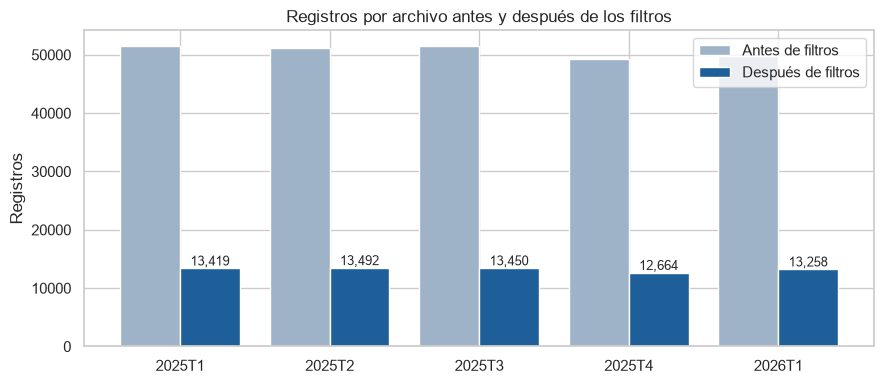

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(antes_despues))
ax.bar(x - 0.2, antes_despues["antes_filtros"], 0.4, label="Antes de filtros", color="#9fb3c8")
ax.bar(x + 0.2, antes_despues["despues_filtros"], 0.4, label="Después de filtros", color="#1f5f99")
for i, r in antes_despues.iterrows():
    ax.text(i + 0.2, r["despues_filtros"], f'{r["despues_filtros"]:,}', ha="center", va="bottom", fontsize=9)
ax.set_xticks(x, antes_despues["periodo_archivo"])
ax.set_ylabel("Registros"); ax.set_title("Registros por archivo antes y después de los filtros")
ax.legend(); plt.tight_layout(); plt.show()

**¿Qué vemos?**

- En 2025 pasamos de **203,676 a 53,025** registros, más o menos 1 de cada 4. En 2026 quedan **13,258**.
- Solo los **3 primeros filtros** quitan gente: menores de 15, personas que no trabajan y quienes trabajan pero **no son asalariados** (por ejemplo, los que trabajan por cuenta propia).
- Los filtros 4 a 8 quitan **0 registros**. Esto quiere decir que los datos de los asalariados ya venían **limpios** (el INE ya los revisó). Igual los dejamos, para aplicarle la misma regla a 2026.
- Todos los trimestres conservan casi el mismo % (~26 %), así que ninguno pierde más datos que otro.

## 1.6 Revisar los códigos con el diccionario

Si un código no está en el diccionario, lo ponemos como `DESCONOCIDO`, **nunca como 0**. En educación, el **0 significa "Ninguno"**: es una respuesta válida, no un dato faltante.

In [14]:
def mapear(col_cod, dic):
    expr = F.lit("DESCONOCIDO")
    for k, v in sorted(dic.items(), reverse=True):
        expr = F.when(F.col(col_cod) == k, F.lit(f"{k}-{v}")).otherwise(expr)
    return F.when(F.col(col_cod).isNull(), F.lit("DESCONOCIDO")).otherwise(expr)

def preparar(df_m):
    return (df_m.filter(F.col("motivo_exclusion") == "0_CONSERVADO")
            .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12)
            .withColumn("nivel_educativo", mapear("cod_nivel_educativo", DIC_NIVEL_EDUCATIVO))
            .withColumn("categoria_ocupacional", mapear("cod_categoria_ocupacional", DIC_CATEGORIA_OCUP))
            .withColumn("dominio", mapear("cod_dominio", DIC_DOMINIO))
            .select("archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
                    "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
                    "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad",
                    "horas_semanales", "nivel_educativo", "categoria_ocupacional", "dominio", "ocupado"))

df2025 = preparar(df2025_m).cache()
df2026 = preparar(df2026_m).cache()

for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    t = (df2025.groupBy(c).count().withColumnRenamed("count", "n_2025")
         .join(df2026.groupBy(c).count().withColumnRenamed("count", "n_2026"), c, "full")
         .orderBy(c).toPandas().fillna(0))
    display(t)

,nivel_educativo,n_2025,n_2026
0,0-NINGUNO,3995,1016
1,1-PREPRIMARIA,459,80
2,2-PRIMARIA,15822,3957
3,3-BÁSICO,8249,2164
4,4-DIVERSIFICADO,16851,4117
5,5-SUPERIOR,6818,1729
6,6-MAESTRÍA,771,183
7,7-DOCTORADO,60,12


,categoria_ocupacional,n_2025,n_2026
0,1-Empleado de gobierno,6575,1646
1,2-Empleado de empresa privada,28702,7503
2,3-Jornalero o peón,13842,3093
3,4-Servicio doméstico,3906,1016


,dominio,n_2025,n_2026
0,1-Urbano Metropolitano,22072,5632
1,2-Resto Urbano,20146,4846
2,3-Rural Nacional,10807,2780


**¿Qué vemos?** No salió **ningún `DESCONOCIDO`**, así que todos los códigos son válidos. Ojo con los grupos **muy pequeños**, como Doctorado (60 personas) o Preprimaria (459): con tan pocas personas, sus promedios pueden ser poco confiables.

## 1.7 ¿Hay registros repetidos?

Revisamos que cada combinación `periodo_archivo + NUM_HOGAR + NUM_PERSONA` aparezca **una sola vez**. Si alguna se repitiera, veríamos si es una copia exacta o si trae datos distintos. **No usamos `dropDuplicates()`**, porque eso escondería el problema.

In [15]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
def revisar_unicidad(df, nombre):
    COLS_CONTENIDO = [c for c in df.columns if c not in CLAVE + ["archivo_origen"]]
    n = df.count()
    n_claves = df.select(*CLAVE).distinct().count()
    nulos_clave = df.filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count()
    dup = df.groupBy(*CLAVE).agg(F.count("*").alias("n"),
                                 F.countDistinct(F.struct(*COLS_CONTENIDO)).alias("versiones")) \
            .filter(F.col("n") > 1)
    resumen = dup.agg(F.count("*").alias("claves_duplicadas"),
                      F.sum("n").alias("filas_involucradas"),
                      F.sum((F.col("versiones") == 1).cast("int")).alias("repeticiones_exactas"),
                      F.sum((F.col("versiones") > 1).cast("int")).alias("claves_en_conflicto")).first()
    return {"base": nombre, "registros": n, "claves_distintas": n_claves,
            "claves_con_nulos": nulos_clave, **{k: (v or 0) for k, v in resumen.asDict().items()}}, dup

res = []
dups = {}
for nombre, df in [("2025 completo", df2025_raw), ("2026 completo", df2026_raw),
                   ("2025 analítico", df2025), ("2026 analítico", df2026)]:
    r, d = revisar_unicidad(df, nombre)
    res.append(r); dups[nombre] = d
pd.DataFrame(res)

,base,registros,claves_distintas,claves_con_nulos,claves_duplicadas,filas_involucradas,repeticiones_exactas,claves_en_conflicto
0,2025 completo,203676,203676,0,0,0,0,0
1,2026 completo,49843,49843,0,0,0,0,0
2,2025 analítico,53025,53025,0,0,0,0,0
3,2026 analítico,13258,13258,0,0,0,0,0


In [16]:
# Si hubiera claves duplicadas, se muestran para investigarlas (no se eliminan)
for nombre, d in dups.items():
    if d.count() > 0:
        print(f"== {nombre}: claves duplicadas ==")
        claves = d.limit(10)
        base = df2025_raw.unionByName(df2026_raw)
        base.join(claves.select(*CLAVE), CLAVE).orderBy(*CLAVE).show(20, truncate=False)

**¿Qué vemos?** **No hay ningún repetido**: hay tantas claves distintas como registros. No hubo que borrar nada.

### La misma persona en varios trimestres

La encuesta **vuelve a visitar a los mismos hogares** en distintos trimestres, así que una persona puede aparecer varias veces. Eso **no es un error**.

In [17]:
apariciones = (df2025.groupBy("NUM_HOGAR", "NUM_PERSONA")
               .agg(F.countDistinct("periodo_archivo").alias("n_periodos"))
               .groupBy("n_periodos").count().orderBy("n_periodos").toPandas())
apariciones["%"] = (100 * apariciones["count"] / apariciones["count"].sum()).round(2)
print(f"Filas analíticas 2025: {df2025.count():,} | combinaciones hogar-persona distintas: {apariciones['count'].sum():,}")
apariciones

Filas analíticas 2025: 53,025 | combinaciones hogar-persona distintas: 26,709


,n_periodos,count,%
0,1,11303,42.32
1,2,7831,29.32
2,3,4240,15.87
3,4,3335,12.49


**¿Qué vemos?** Las 53,025 filas son en realidad unas **26,709 personas**, y más de la mitad (58 %) aparece en 2 o más trimestres. O sea, cada fila es **"una persona en un trimestre"**, no una persona distinta.

## 1.8 Guardar en Parquet

Guardamos 2025 y 2026 **por separado**. Las partes siguientes leen estos archivos.

In [18]:
RUTA_2025 = os.path.join(PARQ_DIR, "eneic_2025_preparado.parquet")
RUTA_2026 = os.path.join(PARQ_DIR, "eneic_2026_preparado.parquet")
df2025.write.mode("overwrite").parquet(RUTA_2025)
df2026.write.mode("overwrite").parquet(RUTA_2026)

df2025 = spark.read.parquet(RUTA_2025).cache()
df2026 = spark.read.parquet(RUTA_2026).cache()
print(f"2025 preparado: {df2025.count():,} filas -> {RUTA_2025}")
print(f"2026 preparado: {df2026.count():,} filas -> {RUTA_2026}")
df2025.printSchema()

2025 preparado: 53,025 filas -> /Users/anggiequezada/Desktop/UVG/Data science/lab7-md/lab7-md/data/parquet/eneic_2025_preparado.parquet
2026 preparado: 13,258 filas -> /Users/anggiequezada/Desktop/UVG/Data science/lab7-md/lab7-md/data/parquet/eneic_2026_preparado.parquet
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_oc

## 1.9 Respuestas del Ejercicio 1

**¿Por qué IV-2025 no se puede apilar por posición de columnas?**
Porque tiene **302 columnas en vez de 270** y cada variable está en **otra posición**. Si pegáramos los archivos por posición, la edad de uno podría quedar debajo de otra pregunta del otro, y Spark no avisaría. Con `unionByName` se juntan por **nombre**, así que cada dato cae en su columna correcta.

**¿Qué diferencia hay entre "no corresponde" y "no registrado"?**
- **No corresponde:** la pregunta **no le tocaba** a esa persona. Por ejemplo, a un niño no se le pregunta su salario. Ese vacío es normal y no hay que rellenarlo.
- **No registrado:** la pregunta **sí le tocaba**, pero no hay respuesta (no quiso contestar, no sabía o hubo un error). Esto sí es información perdida.

En nuestros datos casi todo es del primer tipo, porque al quedarnos solo con los ocupados los faltantes bajan a 0 %.

**¿Por qué no borrar a una persona que aparece en dos trimestres?**
Porque **no es un duplicado**: es la misma persona en **momentos distintos**, y su salario, sus horas o su antigüedad pueden cambiar. Si la borráramos, perderíamos casi la mitad de los datos (de 53,025 a 26,709). Un duplicado de verdad sería la misma persona **dos veces en el mismo trimestre**, y eso no pasó.

**¿Por qué los registros filtrados no representan a todos los trabajadores del país?**
1. **Es una encuesta (muestra)**: cada persona encuestada "representa" a muchas más, y cuántas lo dice el `FACTOR`. Si solo contamos filas, no obtenemos el total del país.
2. **Solo dejamos a los asalariados**. Quedan fuera los que trabajan por su cuenta, los patronos, etc., que son un 40 % de los ocupados de esta muestra.
3. **Hay personas repetidas** en varios trimestres.


